In [2]:
using NLsolve, ForwardDiff, Plots, TaylorSeries, SpecialFunctions
 
function  weights(N)
     z = Taylor1(N)   
        poly = 2*(1-z)/(1+z);
    return poly.coeffs;         
end

weights (generic function with 1 method)

In [3]:
function IntegratorBDF(q₀ ,  p₀ , N ,  T)

ω = weights(N);
   
L(q,v) = (1/2) * v^2 - (1/2) * q^2
    
ρ  = 1/4;    
    
Δt = T/N;

Ld = ((x , y),) -> Δt * L( 0.5 * (x + y) , (y-x) / Δt);
    
    
DL(i) = u -> ForwardDiff.gradient(Ld,u)[i]   # i=1 or 2 corresponds to D₁ or D₂

q = [];   
 
DEL0 = u -> p₀ + DL(1)([q₀ ,u]) - 0.5 * ρ * ω[1] * (u-q₀)/2 ;

init_geuss =  [q₀ + Δt *  p₀];     
    
r = nlsolve(u -> DEL0(u[1]), init_geuss; autodiff = :forward,ftol=1e-14)
    
append!(q,q₀, r.zero); 


for k in 3:N+1  
        
Qnew = u -> (q + vcat(q[2:end],u))/2;
Qold =  (q[1:end-1]+q[2:end])/2  

        
DEL = (q,u) -> DL(2)([q[end-1],q[end]]) + DL(1)([q[end] ,u])- 0.5*ρ * reverse(ω[1:k-2])' * Qold - 0.5*ρ * reverse(ω[1:k-1])' * Qnew(u); 
        
init_geuss = [q[end] + Δt *  p₀];
        
r = nlsolve(u -> DEL(q,u[1]), init_geuss; autodiff = :forward,ftol=1e-14)
#all_converged(res) =  r.f_converged
#@show all_converged(r)
append!(q, r.zero); 
                    
end
  
    return q;
    
end
    

IntegratorBDF (generic function with 1 method)

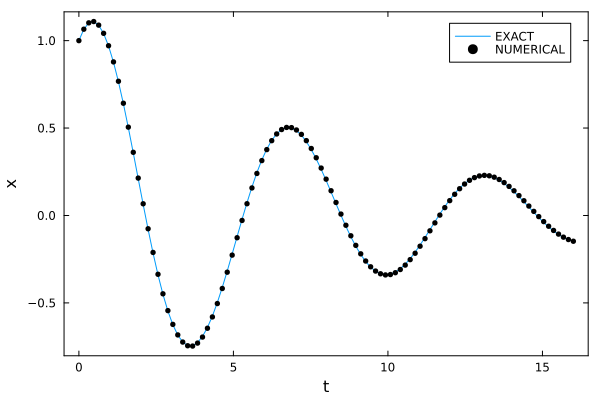

In [5]:
q₀ = 1.0 ;  p₀ = 0.5 ; N = 100 ; T = 16; ts = (0:N)*T/N;
q_exact(t) =  exp( -t/8 ) * cos(3*√7 * t / 8) + exp( -t/8 ) * sin(3*√7 * t / 8) * (5*√7/21);
q  = IntegratorBDF(q₀ , p₀ , N , T);

plt1=plot(ts, q_exact.(ts),label="EXACT")


scatter!(plt1,ts, q,m=:circle,ms=3,mc=:black,label="NUMERICAL")
plot!(plt1,xlabel="t", ylabel="x",grid=false,framestyle=:box)


In [9]:
using LaTeXStrings
Ns=2 .^(4:11)

T = 16;

m = length(Ns);

err = zeros(m)

for i in 1:m

N = Ns[i]; ts = (0:N)*T/N;
    
q = IntegratorBDF(q₀ , p₀ , N , T)

err[i] = norm(q .- q_exact.(ts), Inf)
end    

h = T ./Ns;

f(x)=x^2;


plt2=plot(h , err,label="MIDPOINT" , m =:sq,grid=false,framestyle=:box,xlabel="log₁₀(h)", ylabel="log₁₀(xErr)")
plot!(plt2,h , f.(h) , label=L"O(h^2)")
plot!(plt2,xscale=:log10, yscale=:log10, legend=:topleft)

plot(plt1,plt2,layout=(1,2),legend=:topright)

savefig("1D_Damped_Errors.pdf")

"/home/hariz/Desktop/RKCQ_1206/1D_Damped_Errors.pdf"